# -First project with Python for Deep Learning Courses.
# -We will be using the Pandas, Numpy, Matplotlib and Torch libraries to analyze the data.

In [3]:
## Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

In [4]:
## Data:
data = pd.read_csv('study_hours_grades.csv')

In [5]:
## Exploratory Data Analysis:
print(data.head())
print(data.info())
print(data.describe().T)

   study_hours      grade
0     3.745401  30.203939
1     9.507143  57.878452
2     7.319939  46.368401
3     5.986585  39.330717
4     1.560186  14.843888
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes
None
             count       mean        std        min        25%        50%  \
study_hours   50.0   4.459239   2.888832   0.205845   1.837670   4.360488   
grade         50.0  32.290305  14.431931  11.032281  21.062901  31.231858   

                   75%        max  
study_hours   6.498549   9.699099  
grade        41.683170  60.573564  


In [6]:
## Convert the numpy array to a tensor:
type(torch.tensor(data['study_hours'].values)) # Type is Tensor.
type(torch.tensor(data['study_hours'].values)) # Type is Tensor.

## Describe X and y variables:
y = torch.tensor(data['grade'].values)
X = torch.tensor(data['study_hours'].values)

print(X.shape, y.shape) # Shape of X and y variables.

torch.Size([50]) torch.Size([50])


In [7]:
## Test-Train split:
train_split = int(len(X) * 0.8)
X_train, y_train = X[:train_split], y[:train_split] # 80% of the data for training.
X_test, y_test = X[train_split:], y[train_split:] # 20% of the data for testing.

print(X_train.shape, y_train.shape) # Shape of X_train and y_train variables.
print(X_test.shape, y_test.shape) # Shape of X_test and y_test variables.

torch.Size([40]) torch.Size([40])
torch.Size([10]) torch.Size([10])


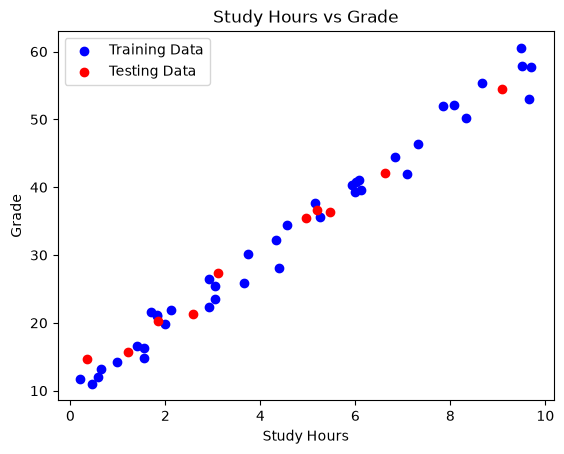

In [8]:
## Draw a scatter plot of the data:
plt.scatter(X_train, y_train, c='blue', label='Training Data')
plt.scatter(X_test, y_test, c='red', label='Testing Data')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.title('Study Hours vs Grade')
plt.legend()
plt.show()

In [9]:
## Build a simple artifical neural network:
class SimpleLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32), requires_grad=True) # Randomly initialize the weights.
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32), requires_grad=True) # Randomly initialize the bias.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias # Forward pass.

## Initialize the model:
torch.manual_seed(42) # Set the random seed for reproducibility.
model = SimpleLinearRegressionModel()

In [10]:
## State_Dict and Parameters:
print(list(model.parameters()))
print(list(model.state_dict()))

## Make predictions:
with torch.inference_mode():
    y_preds = model(X_test)
print(y_preds)
print(y_test)

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
['weights', 'bias']
tensor([0.5397, 1.7960, 0.2446, 3.1904, 1.0001, 2.3595, 1.1783, 1.8798, 1.9695,
        0.7512], dtype=torch.float64)
tensor([15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)


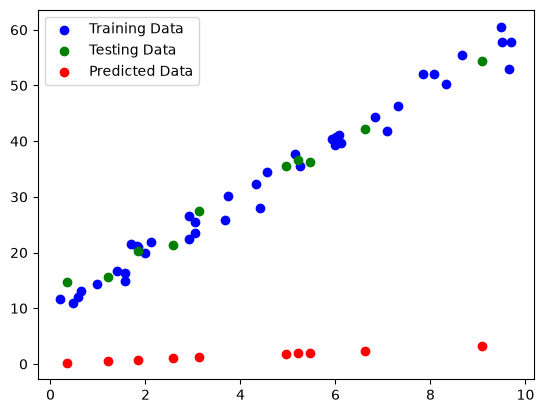

In [11]:
## Visualize the model:
plt.scatter(X_train, y_train, c='blue', label='Training Data')
plt.scatter(X_test, y_test, c='green', label='Testing Data')
plt.scatter(X_test, y_preds, c='red', label='Predicted Data')
plt.legend()
plt.show() # We didn't train the model yet, so the predictions are not good.

In [13]:
## Train the model:
epoch_count = []
train_loss_values = []
test_loss_values = []
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

torch.manual_seed(42)
for epoch in range(200):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad() # This three steps are being backpropagation.
    loss.backward() #
    optimizer.step() # 

    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy()) # Matplotlib Library doesn't support torch tensor so we have to convert it to numpy array.
            test_loss_values.append(test_loss.detach().numpy()) # Same as above.
            print(f"Epoch: {epoch}, Loss: {loss.detach().numpy()}, Test Loss: {test_loss.detach().numpy()}")

Epoch: 0, Loss: 31.0901825712162, Test Loss: 28.745246368360664
Epoch: 10, Loss: 28.908399018732535, Test Loss: 26.79939133912989
Epoch: 20, Loss: 26.72661638642352, Test Loss: 24.85353751421489
Epoch: 30, Loss: 24.54483515859551, Test Loss: 22.9076846836413
Epoch: 40, Loss: 22.36305172532114, Test Loss: 20.961829411917666
Epoch: 50, Loss: 20.181265058383016, Test Loss: 19.01597175864862
Epoch: 60, Loss: 17.999478391444892, Test Loss: 17.070114105379577
Epoch: 70, Loss: 15.817691724506773, Test Loss: 15.124256452110535
Epoch: 80, Loss: 13.635905057568646, Test Loss: 13.178399763380582
Epoch: 90, Loss: 11.454119418847904, Test Loss: 11.232542050506895
Epoch: 100, Loss: 9.272332751909783, Test Loss: 9.286684397237853
Epoch: 110, Loss: 7.090546084971661, Test Loss: 7.340826743968809
Epoch: 120, Loss: 5.325303867375498, Test Loss: 5.610128744338432
Epoch: 130, Loss: 4.431128834471838, Test Loss: 4.876347952298718
Epoch: 140, Loss: 4.047925770415359, Test Loss: 4.601726984324496
Epoch: 150,

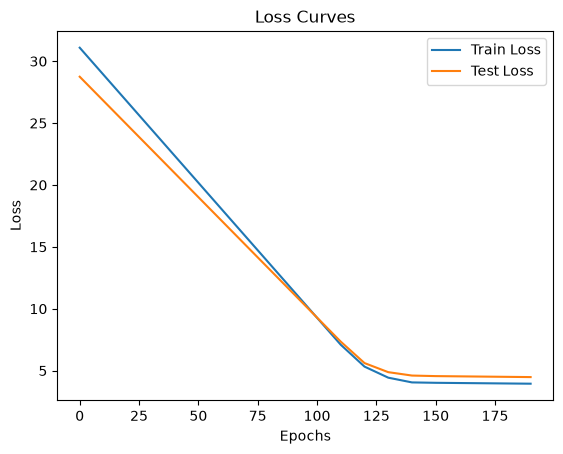

-------------------------
OrderedDict({'weights': tensor([6.2369]), 'bias': tensor([1.7278])})
-------------------------


In [14]:
## Plot Loss Curves:
plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()  
    
print("-"*25)
print(model.state_dict())
print("-"*25)


tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)
tensor([ 9.3392, 32.6116,  3.8726, 58.4415, 17.8677, 43.0489, 21.1690, 34.1641,
        35.8257, 13.2570], dtype=torch.float64)

-------------------------


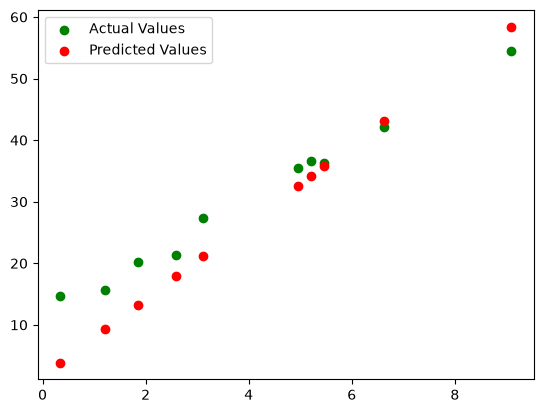

In [15]:
## Evaluate the model results:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

print(X_test)
print(y_preds)

print("\n" + "-"*25)
plt.scatter(X_test, y_test, c='green', label='Actual Values')
plt.scatter(X_test, y_preds, c='red', label='Predicted Values')
plt.legend()
plt.show()  